## Hybrid Agent

In [2]:
query='What is 25*3? Also explain AI in brief'

# Query Decomposition

# q1='What is 25*3?' -> router -> calculator...
# q2= 'Explain AI in brief' -> router -> fallback...

In [1]:
# Hybrid Agent
# ├── Graph
# │   └── graph.compile()
# │       └── Agentic Workflow
# │           └── Controlled by us
# │
# └── Agent
#     └── create_agent()
#         └── True Agent
#             └── Loop
#                 └── Controlled by LLM

In [3]:
# Problem
# ├── Deterministic
# │   └── Graph Flow
# │       └── Query
# │           └── Decision
# │               └── Tool
# │                   └── Final Response
# │
# └── Probabilistic
#     └── Agent
#         └── Final Answer

In [4]:
# Query
# ├── Simple Task
# │   └── Graph
# │       └── Final Answer
# │
# └── Complex Task
#     └── Agent
#         └── (Reasoning / Retry)
#             └── Final Answer

In [21]:
import os
import re
from typing import TypedDict
from datetime import datetime
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langgraph.graph import StateGraph, END
from tavily import TavilyClient

### State

In [2]:
class AgentState(TypedDict):
    query: str
    route: str
    result: str
    
AgentState

__main__.AgentState

In [3]:
tavily_client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))
tavily_client

In [4]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'),
                 model='gpt-4o-mini',
                 temperature=0)

llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000020E77039D10>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000020E77569B90>, root_client=<openai.OpenAI object at 0x0000020E770371D0>, root_async_client=<openai.AsyncOpenAI object at 0x0000020E77569710>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

### Tools

In [46]:
@tool
def web_search_tool(query: str) -> str:
    '''Search the web for the current information'''
    print('[Tool - Web Search]')
    print(query)
    
    response = tavily_client.search(query=query, max_results=3)
    print("response")
    print(response)
    
    results = []
    for res in response['results']:
        results.append(res['content'])
        
    print("results")
    print(results)
    
    return '\n'.join(results)

web_search_tool

StructuredTool(name='web_search_tool', description='Search the web for the current information', args_schema=<class 'langchain_core.utils.pydantic.web_search_tool'>, func=<function web_search_tool at 0x0000020E78DB7D80>)

In [24]:
def calculator_tool(expression: str) -> str:
    print('\n[Tool - Calculator]: ', expression)
    return eval(expression)

def current_time_tool(_:str = '') -> str:
    print('\n[Tool - Current Time]')
    return datetime.now().strftime('%Y-%m-%d %H:%M:%S')

### Create Agent

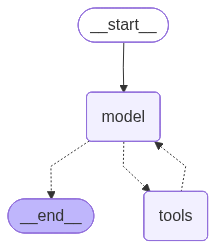

In [49]:
pure_agent = create_agent(
    model = llm,
    tools = [web_search_tool],
    system_prompt='''You are a helpful assistant!
Use the web_search_tool when the question requires current information.'''
)

pure_agent

### Nodes

In [47]:
def router_node(state):
    print('\n[ROUTER NODE]')

    query=state['query']

    prompt=f"""Decide route based on the given query.
    
- calculator (math related queries)
- time (time queries)
- agent (complex/ general queries)

QUERY:
{query}

Return only the name of the route."""

    result = llm.invoke(prompt).content.strip().lower()

    print('Route', result)

    return {'route' :result}

In [26]:
def get_math_expression(text):
    print('\n[Helper - Get Math Exp]')

    text = text.replace(',', '').replace('\\', '')
    text = text.replace('x', '*')
    
    match = re.findall(r'[0-9+\-/*%^().]+', text)
    
    if match:
        return match[0].strip()
    
    return text.strip()

In [27]:
def calculator_node(state):
    print('\n[CALCULATOR NODE]')
    
    exp = get_math_expression(state['query'])
    result = calculator_tool(exp)
    return {'result': result}

In [28]:
def current_time_node(state):
    print('\n[CURRENT TIME NODE]')
    result = current_time_tool()
    
    return {'result': result}

In [29]:
def agent_node(state):
    print('\n[AGENT NODE]')
    
    response = pure_agent.invoke(
        {
            'messages': [
                {'role': 'user', 'content': state['query']}
            ]
        }
    )
    
    print(response['messages'])
    result = response['messages'][-1].content
    
    return {'result': result}

### Flow

In [50]:
graph = StateGraph(AgentState)

graph.add_node('router_n', router_node)
graph.add_node('calculator_n', calculator_node)
graph.add_node('current_time_n', current_time_node)
graph.add_node('agent_n', agent_node)

In [35]:
def router_helper(state):
    print('\n[Helper - Router]')
    return state['route']

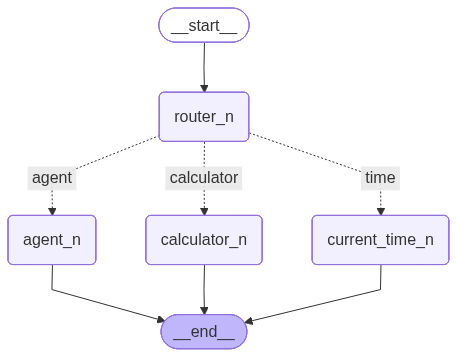

In [51]:
graph.add_conditional_edges('router_n',
                            router_helper,
                            {
                                'agent': 'agent_n',
                                'calculator': 'calculator_n',
                                'time': 'current_time_n'
                            })

graph.add_edge('agent_n', END)
graph.add_edge('current_time_n', END)
graph.add_edge('calculator_n', END)

graph.set_entry_point('router_n')

app = graph.compile()
app

### Agent Call

In [39]:
def agent_call():
    while True:
        query = input('Ask (type exit to quit): ')
        
        if query.lower() in ['exit', 'quit', 'stop', 'end']:
            print('exiting......')
            break
        
        result = app.invoke(
            {'query': query}
        )
            
        print(f"\nFinal Answer: {result}")

In [40]:
agent_call()


[ROUTER NODE]
Route calculator

[Helper - Router]

[CALCULATOR NODE]

[Helper - Get Math Exp]

[Tool - Calculator]:  678*23

Final Answer: {'query': 'what is 678*23', 'route': 'calculator', 'result': 15594}
exiting......


In [41]:
agent_call()


[ROUTER NODE]
Route time

[Helper - Router]

[CURRENT TIME NODE]

[Tool - Current Time]

Final Answer: {'query': 'what is the time now', 'route': 'time', 'result': '2026-04-01 14:35:08'}
exiting......


In [43]:
agent_call()


[ROUTER NODE]
Route agent

[Helper - Router]

[AGENT NODE]
[HumanMessage(content='agentic workflow vs pure agent', additional_kwargs={}, response_metadata={}, id='f727d36b-7c52-442a-aca4-1c7a6557be93'), AIMessage(content='The terms "agentic workflow" and "pure agent" are often used in discussions about artificial intelligence, automation, and decision-making processes. Here\'s a breakdown of each concept:\n\n### Agentic Workflow\n- **Definition**: An agentic workflow refers to a structured process where an agent (which can be a human or an AI) operates within a defined framework to achieve specific goals. This workflow often involves multiple steps, decision points, and interactions with other agents or systems.\n- **Characteristics**:\n  - **Collaboration**: It may involve collaboration between multiple agents (human and/or AI).\n  - **Contextual Awareness**: The agent is aware of its environment and can adapt its actions based on changing conditions.\n  - **Feedback Loops**: There a

In [52]:
agent_call()


[ROUTER NODE]
Route agent

[Helper - Router]

[AGENT NODE]
[Tool - Web Search]
hybrid agents in AI
[Tool - Web Search]
25*3
response
{'query': 'hybrid agents in AI', 'response_time': 0.65, 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://milvus.io/ai-quick-reference/what-are-hybrid-agents-in-ai', 'title': 'What are hybrid agents in AI? - Milvus', 'content': 'What are hybrid agents in AI? # What are hybrid agents in AI? Hybrid agents in AI are systems that combine multiple AI techniques to solve complex problems more effectively than single-method approaches. These agents typically integrate symbolic AI (rule-based systems) with machine learning (data-driven methods) to leverage the strengths of both. For example, a hybrid agent might use predefined rules to handle structured decision-making while employing neural networks to adapt to unpredictable scenarios. For instance, in autonomous robotics, a hybrid agent might use rule-based logic to naviga

In [55]:
# Fallback Node - Plain LLM Call 
# Agent Node - Autonomous Agent System